# Get Z-scores for replicates, calculate median between Z-scores, and generate PCA

In [1]:
%reload_ext autoreload
%autoreload 2
def warn(*args, **kwargs):
    pass  # to silence scikit-learn warnings

import warnings
warnings.filterwarnings('ignore')
warnings.warn = warn

# Type hints
from typing import Iterable, List, Set, Dict, Union, Optional

import pandas as pd

from rdkit import DataStructs
from rdkit.Chem import AllChem as Chem

import sys
sys.path.append(r"/home/f.garciafossa/projects/notebooks_pahl/paint3_anal/cellpainting3")
from cellpainting3 import processing as cpp, tools as cpt

# import matplotlib.pyplot as plt
# import seaborn as sns
from tqdm.notebook import tqdm
tqdm.pandas()

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

sys.path.append(r"/home/f.garciafossa/projects/notebooks_pahl/paint3_anal")
# Project-local Imports
from jupy_tools import plt_style
from jupy_tools import utils as u, mol_view as mv
from jupy_tools.utils import info
u.timestamp()

import utils

sys.path.append(f"/home/f.garciafossa/github/cellprofiler4-deepchem/cellpainting4")

from analysis.analysis_utils import force_set_cp_config

import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from scipy.spatial.distance import cdist

cellpainting3.processing                      (250812-13:03)
No clusters found in /home/f.garciafossa/projects/clusters/experimental_clusters.
* WARNING: No functional clusters found.
Timestamp: 06-May-2026 08:49:18


In [2]:
cpt, cpp = force_set_cp_config(
    f"/home/f.garciafossa/projects/cp_data_exploration/2025_tom_paper/20260504_review/2026_03_config.yaml", # OR NEW NAME
    prefer_local_tree=f"/home/f.garciafossa/github/cellpainting3"
)

cellpainting3.processing                      (260505-15:33)
No clusters found in /home/f.garciafossa/projects/clusters/experimental_clusters.
* WARNING: No functional clusters found.
Using config YAML: /home/f.garciafossa/projects/cp_data_exploration/2025_tom_paper/20260504_review/2026_03_config.yaml
tools.py from     : /home/f.garciafossa/github/cellpainting3/cellpainting3/tools.py
processing.py from: /home/f.garciafossa/github/cellpainting3/cellpainting3/processing.py
PlatesDir (tools) : /home/f.garciafossa/projects/cellpainting/plates
PlatesDir (proc)  : /home/f.garciafossa/projects/cellpainting/plates


## Import datastore

In [3]:
cpp.load_resource("DATASTORE")
df = cpp.DATASTORE.compute()
info(df)

cellpainting3.processing                      (260505-15:33)
No clusters found in /home/f.garciafossa/projects/clusters/experimental_clusters.
* WARNING: No functional clusters found.
  - loading resource:                      (DATASTORE)
    
Dataset created on 2026-03-05T15:46:15.382437 (public)
        Removed plates: set()
        New plates: {'C2026-01-50.00-20h-260220', 'C2026-01-03.00-20h-260220', 'C2026-01-30.00-20h-260220', 'C2026-01-10.00-20h-260220'}

Shape                              : [   63223 / 626 ] 


In [4]:
df["Plate_Conc"] = df["Plate"].str.split("-")
df["Date"] = df["Plate_Conc"].apply(lambda x: x[-1])
df = df.query("Date != '260220'").reset_index(drop=True)

In [5]:
COMP_ID_COL = 'Compound_Id'
CONC_COL = 'Conc_uM' 
TOXIC_COL = 'Toxic'     
TIME_COL = None 
TIME_KEEP = None     
FEATURE_PREFIX = 'Median_'
aggfunc = 'median'                  
COMP_COL = 'Compound_Id'
COMPARTMENTS_ORDER = ['Median_Cells', 'Median_Cytoplasm', 'Median_Nuclei']
CHANNELS_ORDER = ['Mito', 'Ph_golgi', 'Syto', 'ER', 'Hoechst']

In [6]:
compounds_to_keep = [
    411147,
    537920,
    537917,
    537924,
    538476
]

COMPOUND_RENAME = {
    411147: "Ava",
    537917: "43",
    537920: "44",
    537924: "45",
    538476: "48"
}

In [7]:
filtered_df = df[df['Compound_Id'].isin(compounds_to_keep)].reset_index(drop=True)
anno = u.read_tsv("/home/f.garciafossa/projects/cellpainting/resources/known_act.tsv")
ds = pd.merge(filtered_df, anno, on="Compound_Id", how="left")

ds.sort_values(by=["Compound_Id", "Conc_uM"], inplace=True, ignore_index=True)
metadata = [
            'Plate', 'Compound_Id', 'Well_Id', 'Supplier_Id',
'Is_Ref', 'Conc_uM', 'TP', 'Activity', 'OverAct', 'Pure_Flag', 'Toxic', 'Rel_Cell_Count', 'Producer',
'Cluster_High', 'Cluster_Sim',
'Cluster_AKT_PI3K_MTOR', 'Cluster_Aurora', 'Cluster_BET', 'Cluster_Calpain_Protease', 'Cluster_DNA_Synth', 'Cluster_ER_Stress', 'Cluster_Forskolin', 'Cluster_HDAC', 'Cluster_HSP90', 'Cluster_LCH', 'Cluster_MitoStress', 'Cluster_NEDD8', 'Cluster_Na_K-ATPase', 'Cluster_Proteasome', 'Cluster_Protein_Synth', 'Cluster_Protein_Synth_High', 'Cluster_Pyrimidine_Synth', 'Cluster_ROCK_all', 'Cluster_ROCK_high', 'Cluster_ROCK_low', 'Cluster_TGFRB', 'Cluster_Tubulin', 'Cluster_Uncoupler',
'Chiral', 'Smiles',]

read_tsv                           : [   13378 /   3 ] ( Compound_Id, Trivial_Name, Known_Act )


In [8]:
ds[["Plate", "Trivial_Name", "Compound_Id", "Cluster_High", "Well_Id", "Activity", "Conc_uM", "Rel_Cell_Count"]]

,Plate,Trivial_Name,Compound_Id,Cluster_High,Well_Id,Activity,Conc_uM,Rel_Cell_Count
0,P2201-1-01.00-20h-220325,Avapritinib,411147,Forskolin,411147:03:03_000.100_20h,0.7,0.1,104
1,P2201-1-03.00-20h-220325,Avapritinib,411147,Forskolin,411147:03:03_000.300_20h,4.3,0.3,106
2,FDA2301-2-01.00-20h-230512,Avapritinib,411147,Forskolin,411147:06:02_000.500_20h,6.4,0.5,108
3,P2301-1-01.00-20h-230120,Avapritinib,411147,Forskolin,411147:04:08_001.000_20h,40.8,1.0,98
4,P2201-1-10.00-20h-220325,Avapritinib,411147,Forskolin,411147:03:03_001.000_20h,28.8,1.0,105
5,P2002-1-01.00-20h-200714,Avapritinib,411147,Forskolin,411147:01:11_001.000_20h,45.4,1.0,99
6,P2002-1-03.00-20h-200714,Avapritinib,411147,Forskolin,411147:01:11_003.000_20h,65.5,3.0,101
7,P2301-1-03.00-20h-230120,Avapritinib,411147,ER_Stress,411147:04:08_003.000_20h,75.6,3.0,103
8,C2019-06-10.00-20h-191105,Avapritinib,411147,LCH,411147:01:03_010.000_20h,75.1,10.0,98
9,C2022-03-10.00-20h-220506,Avapritinib,411147,ER_Stress,411147:04:03_010.000_20h,86.9,10.0,93


In [10]:
# List of (Compound_Name, Conc_uM) you want
targets = [
    ("Ava", 10.0),
    ("Ava", 3.0),
    ("Ava", 1.0),
    ("43", 1.0),
    ("43", 3.0),
    ("43", 5.0),
    ("43", 10.0),
    ("44", 3.0),
    ("44", 5.0),
    ("44", 10.0),
    ("45", 3.0),
    ("45", 5.0),
    ("48", 3.0),
    ("48", 10.0),
]

df_filtered = ds[[
    "Plate",
    "Trivial_Name",
    "Compound_Id",
    "Cluster_High",
    "Well_Id",
    "Activity",
    "Conc_uM",
    "Rel_Cell_Count"
]].copy()

df_filtered["Compound_Name"] = (
    df_filtered["Compound_Id"]
    .map(COMPOUND_RENAME)
    .fillna(df_filtered["Compound_Id"].astype(str))
)

df_filtered = df_filtered[
    df_filtered[["Compound_Name", "Conc_uM"]]
    .apply(tuple, axis=1)
    .isin(targets)
].copy()

df_filtered = df_filtered.sort_values(
    ["Compound_Name", "Conc_uM", "Plate", "Well_Id"]
)

summary_plate_reps = (
    df_filtered
    .groupby(["Compound_Id", "Compound_Name", "Conc_uM"], sort=False)
    .agg(
        n_replicates=("Well_Id", "count"),
        plates=("Plate", list),
        wells=("Well_Id", list),
        Induction=("Activity", list),
        Rel_Cell_Count=("Rel_Cell_Count", list),
    )
    .reset_index()
)

summary_plate_reps

,Compound_Id,Compound_Name,Conc_uM,n_replicates,plates,wells,Induction,Rel_Cell_Count
0,537917,43,1.0,1,[C2025-03-10.00-20h-251007],[537917:01:08_001.000_20h],[10.4],[98]
1,537917,43,3.0,2,"[C2025-01-03.00-20h-250905, C2025-03-30.00-20h-251007]","[537917:01:04_003.000_20h, 537917:01:08_003.000_20h]","[22.8, 32.8]","[99, 101]"
2,537917,43,5.0,1,[C2025-03-50.00-20h-251007],[537917:01:08_005.000_20h],[31.6],[100]
3,537917,43,10.0,1,[C2025-01-10.00-20h-250905],[537917:01:04_010.000_20h],[56.3],[94]
4,537920,44,3.0,2,"[C2025-01-03.00-20h-250905, C2025-03-30.00-20h-251007]","[537920:01:04_003.000_20h, 537920:01:08_003.000_20h]","[25.7, 7.1]","[103, 95]"
5,537920,44,5.0,1,[C2025-03-50.00-20h-251007],[537920:01:08_005.000_20h],[16.1],[97]
6,537920,44,10.0,1,[C2025-01-10.00-20h-250905],[537920:01:04_010.000_20h],[40.8],[95]
7,537924,45,3.0,2,"[C2025-01-30.00-20h-250905, C2025-03-30.00-20h-251007]","[537924:01:04_003.000_20h, 537924:01:07_003.000_20h]","[6.9, 10.4]","[101, 101]"
8,537924,45,5.0,2,"[C2025-01-50.00-20h-250905, C2025-03-50.00-20h-251007]","[537924:01:04_005.000_20h, 537924:01:07_005.000_20h]","[19.5, 13.8]","[99, 93]"
9,538476,48,3.0,1,[C2025-02-03.00-20h-250909],[538476:01:04_003.000_20h],[35.2],[104]


# Export withtout aggregation

In [12]:
feature_cols = [
    c for c in ds.columns
    if c.startswith(tuple(COMPARTMENTS_ORDER))
]


metadata_cols = [
    "Plate",
    "Trivial_Name",
    "Compound_Id",
    "Cluster_High",
    "Well_Id",
    "Conc_uM",
    "Activity",
    "Rel_Cell_Count"
]

df_raw = ds[metadata_cols + feature_cols].copy()

df_raw = df_raw.query("not Activity <= 10.0").reset_index(drop=True)

df_raw["Compound_Name"] = (
    df_raw["Compound_Id"]
    .map(COMPOUND_RENAME)
    .fillna(df_raw["Compound_Id"].astype(str))
)

df_raw = df_raw[
    df_raw[["Compound_Name", "Conc_uM"]]
    .apply(tuple, axis=1)
    .isin(targets)
].copy()

df_raw = df_raw.rename(columns={"Activity": "Induction"})

df_raw = df_raw.sort_values(
    ["Compound_Name", "Conc_uM", "Plate", "Well_Id"]
)

df_raw.shape

(22, 588)

## ALL INDIVIDUAL MEASUREMENTS

In [23]:
df_raw["Sample_Label"] = (
    df_raw["Compound_Name"].astype(str)
    + " (" + df_raw["Conc_uM"].astype(str) + " µM)"
    + " | " + df_raw["Plate"].astype(str)
    + " | " + df_raw["Well_Id"].astype(str)
    + " | Induction=" + df_raw["Induction"].round(1).astype(str)
)

df_features_wide = (
    df_raw
    .set_index("Sample_Label")[feature_cols]
    .T
    .reset_index()
    .rename(columns={"index": "Feature Z-score"})
)

df_features_wide.to_excel("20260506_targets_individual_replicates_metadata_and_features.xlsx", index=False)


df_features_wide

Sample_Label,Feature Z-score,43 (1.0 µM) | C2025-03-10.00-20h-251007 | 537917:01:08_001.000_20h | Induction=10.4,43 (3.0 µM) | C2025-01-03.00-20h-250905 | 537917:01:04_003.000_20h | Induction=22.8,43 (3.0 µM) | C2025-03-30.00-20h-251007 | 537917:01:08_003.000_20h | Induction=32.8,43 (5.0 µM) | C2025-03-50.00-20h-251007 | 537917:01:08_005.000_20h | Induction=31.6,43 (10.0 µM) | C2025-01-10.00-20h-250905 | 537917:01:04_010.000_20h | Induction=56.3,44 (3.0 µM) | C2025-01-03.00-20h-250905 | 537920:01:04_003.000_20h | Induction=25.7,44 (5.0 µM) | C2025-03-50.00-20h-251007 | 537920:01:08_005.000_20h | Induction=16.1,44 (10.0 µM) | C2025-01-10.00-20h-250905 | 537920:01:04_010.000_20h | Induction=40.8,45 (3.0 µM) | C2025-03-30.00-20h-251007 | 537924:01:07_003.000_20h | Induction=10.4,...,48 (10.0 µM) | C2025-02-10.00-20h-250909 | 538476:01:04_010.000_20h | Induction=72.5,Ava (1.0 µM) | P2002-1-01.00-20h-200714 | 411147:01:11_001.000_20h | Induction=45.4,Ava (1.0 µM) | P2201-1-10.00-20h-220325 | 411147:03:03_001.000_20h | Induction=28.8,Ava (1.0 µM) | P2301-1-01.00-20h-230120 | 411147:04:08_001.000_20h | Induction=40.8,Ava (3.0 µM) | P2002-1-03.00-20h-200714 | 411147:01:11_003.000_20h | Induction=65.5,Ava (3.0 µM) | P2301-1-03.00-20h-230120 | 411147:04:08_003.000_20h | Induction=75.6,Ava (10.0 µM) | C2019-06-10.00-20h-191105 | 411147:01:03_010.000_20h | Induction=75.1,Ava (10.0 µM) | C2022-03-10.00-20h-220506 | 411147:03:06_010.000_20h | Induction=81.3,Ava (10.0 µM) | C2022-03-10.00-20h-220506 | 411147:04:03_010.000_20h | Induction=86.9,Ava (10.0 µM) | P2301-1-10.00-20h-230120 | 411147:04:08_010.000_20h | Induction=85.3
0,Median_Cells_AreaShape_Area,-2.021,-3.712,-2.625,-3.867,-7.476,-2.950,-2.789,-5.245,-3.202,...,-12.554,-8.522,-4.378,-8.377,-10.963,-13.543,-15.172,-21.608,-23.266,-20.180
1,Median_Cells_AreaShape_MaximumRadius,-2.583,-3.621,-3.498,-4.804,-5.805,-1.933,-4.804,-3.303,-3.688,...,-10.867,-7.030,-3.077,-7.764,-13.153,-12.857,-22.310,-21.881,-24.863,-34.843
2,Median_Cells_AreaShape_MeanRadius,-1.517,-2.598,-2.815,-5.017,-4.684,-2.874,-4.331,-2.243,-4.435,...,-10.450,-7.193,-4.819,-7.702,-13.738,-12.697,-19.070,-23.434,-25.867,-25.317
3,Median_Cells_AreaShape_MinFeretDiameter,-1.526,-2.835,-2.292,-2.623,-9.821,-2.280,-3.196,-8.542,-2.913,...,-12.312,-6.055,-2.671,-8.471,-11.694,-15.393,-18.792,-26.794,-30.164,-35.813
4,Median_Cells_AreaShape_MinorAxisLength,-2.008,-2.816,-4.922,-2.879,-7.363,-1.713,-3.846,-5.181,-3.890,...,-13.195,-6.310,-3.283,-8.142,-11.003,-15.619,-16.543,-30.191,-34.482,-32.250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
574,Median_Nuclei_Texture_Variance_Mito_3_00,0.744,2.111,1.512,0.872,2.930,2.809,0.185,1.197,1.080,...,2.769,8.304,4.707,1.902,9.184,4.288,5.690,1.717,5.259,11.354
575,Median_Nuclei_Texture_Variance_Mito_5_00,0.676,2.290,1.544,0.829,3.073,2.683,0.170,1.214,1.107,...,2.876,8.730,4.733,2.006,9.042,4.372,6.173,1.856,5.473,11.592
576,Median_Nuclei_Texture_Variance_Ph_golgi_10_00,0.927,1.047,4.203,0.117,3.187,2.526,-1.104,1.162,-1.730,...,12.631,1.366,-1.966,-0.550,0.696,4.183,7.232,10.460,9.871,7.562
577,Median_Nuclei_Texture_Variance_Ph_golgi_3_00,0.653,0.785,4.512,0.870,3.448,1.229,-0.237,-0.089,-1.571,...,9.589,1.120,-2.137,-0.584,0.557,4.044,7.070,11.587,10.119,6.117


## AGREGGATED BY MEDIAN

In [24]:
# Metadata columns to keep after aggregation
group_cols = [
    "Compound_Id",
    "Compound_Name",
    "Conc_uM",
]

# Median aggregation by Compound_Id + Conc_uM
df_raw_median = (
    df_raw
    .groupby(group_cols, as_index=False)
    .agg(
        n_replicates=("Well_Id", "count"),
        plates=("Plate", lambda x: sorted(x.unique())),
        wells=("Well_Id", list),
        Induction=("Induction", "median"),
        **{c: (c, "median") for c in feature_cols}
    )
)

df_raw_median["Sample_Label"] = (
    df_raw_median["Compound_Name"].astype(str)
    + " (" + df_raw_median["Conc_uM"].astype(str) + " µM)"
    + " | n=" + df_raw_median["n_replicates"].astype(str)
    + " | median Induction=" + df_raw_median["Induction"].round(1).astype(str)
)

df_features_wide_median = (
    df_raw_median
    .set_index("Sample_Label")[feature_cols]
    .T
    .reset_index()
    .rename(columns={"index": "Feature Z-score"})
)

df_features_wide_median.to_excel(
    "20260506_all_features_targets_median_by_compound_conc.xlsx",
    index=False
)

df_features_wide_median

Sample_Label,Feature Z-score,Ava (1.0 µM) | n=3 | median Induction=40.8,Ava (3.0 µM) | n=2 | median Induction=70.6,Ava (10.0 µM) | n=4 | median Induction=83.3,43 (1.0 µM) | n=1 | median Induction=10.4,43 (3.0 µM) | n=2 | median Induction=27.8,43 (5.0 µM) | n=1 | median Induction=31.6,43 (10.0 µM) | n=1 | median Induction=56.3,44 (3.0 µM) | n=1 | median Induction=25.7,44 (5.0 µM) | n=1 | median Induction=16.1,44 (10.0 µM) | n=1 | median Induction=40.8,45 (3.0 µM) | n=1 | median Induction=10.4,45 (5.0 µM) | n=2 | median Induction=16.6,48 (3.0 µM) | n=1 | median Induction=35.2,48 (10.0 µM) | n=1 | median Induction=72.5
0,Median_Cells_AreaShape_Area,-8.377,-12.2530,-20.8940,-2.021,-3.1685,-3.867,-7.476,-2.950,-2.789,-5.245,-3.202,-2.5465,-5.229,-12.554
1,Median_Cells_AreaShape_MaximumRadius,-7.030,-13.0050,-23.5865,-2.583,-3.5595,-4.804,-5.805,-1.933,-4.804,-3.303,-3.688,-2.9280,-5.312,-10.867
2,Median_Cells_AreaShape_MeanRadius,-7.193,-13.2175,-24.3755,-1.517,-2.7065,-5.017,-4.684,-2.874,-4.331,-2.243,-4.435,-2.9750,-5.036,-10.450
3,Median_Cells_AreaShape_MinFeretDiameter,-6.055,-13.5435,-28.4790,-1.526,-2.5635,-2.623,-9.821,-2.280,-3.196,-8.542,-2.913,-3.0875,-5.818,-12.312
4,Median_Cells_AreaShape_MinorAxisLength,-6.310,-13.3110,-31.2205,-2.008,-3.8690,-2.879,-7.363,-1.713,-3.846,-5.181,-3.890,-2.0555,-5.717,-13.195
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
574,Median_Nuclei_Texture_Variance_Mito_3_00,4.707,6.7360,5.4745,0.744,1.8115,0.872,2.930,2.809,0.185,1.197,1.080,0.2710,3.099,2.769
575,Median_Nuclei_Texture_Variance_Mito_5_00,4.733,6.7070,5.8230,0.676,1.9170,0.829,3.073,2.683,0.170,1.214,1.107,0.1785,3.335,2.876
576,Median_Nuclei_Texture_Variance_Ph_golgi_10_00,-0.550,2.4395,8.7165,0.927,2.6250,0.117,3.187,2.526,-1.104,1.162,-1.730,-1.2150,0.758,12.631
577,Median_Nuclei_Texture_Variance_Ph_golgi_3_00,-0.584,2.3005,8.5945,0.653,2.6485,0.870,3.448,1.229,-0.237,-0.089,-1.571,-1.4515,1.271,9.589


## PCA FROM AGGREGATED DATA

In [15]:
def parse_sample_name(name):
    if not isinstance(name, str):
        return None, np.nan

    match = re.search(r"\(([\d\.]+)\s*µM\)", name)
    if match is None:
        return None, np.nan

    compound = name.split("(")[0].strip()
    conc = float(match.group(1))

    return compound, conc

df_clean = df_features_wide_median.copy()
df_clean = df_clean.set_index("Feature Z-score").T
df_clean.head()

Feature Z-score,Median_Cells_AreaShape_Area,Median_Cells_AreaShape_MaximumRadius,Median_Cells_AreaShape_MeanRadius,Median_Cells_AreaShape_MinFeretDiameter,Median_Cells_AreaShape_MinorAxisLength,Median_Cells_AreaShape_Perimeter,Median_Cells_Correlation_Correlation_ER_Ph_golgi,Median_Cells_Correlation_Correlation_ER_Syto,Median_Cells_Correlation_Correlation_Hoechst_ER,Median_Cells_Correlation_Correlation_Hoechst_Mito,...,Median_Nuclei_Texture_SumVariance_Mito_5_00,Median_Nuclei_Texture_SumVariance_Ph_golgi_10_00,Median_Nuclei_Texture_SumVariance_Ph_golgi_3_00,Median_Nuclei_Texture_SumVariance_Ph_golgi_5_00,Median_Nuclei_Texture_Variance_Mito_10_00,Median_Nuclei_Texture_Variance_Mito_3_00,Median_Nuclei_Texture_Variance_Mito_5_00,Median_Nuclei_Texture_Variance_Ph_golgi_10_00,Median_Nuclei_Texture_Variance_Ph_golgi_3_00,Median_Nuclei_Texture_Variance_Ph_golgi_5_00
Sample_Label,,,,,,,,,,,,,,,,,,,,,
Ava (1.0 µM) | n=3 | median Induction=40.8,-8.3770,-7.0300,-7.1930,-6.0550,-6.3100,-7.6580,-1.9910,-2.213,-4.7110,-4.1820,...,4.317,-0.6260,-0.4070,-0.242,5.1980,4.7070,4.733,-0.5500,-0.5840,-0.5970
Ava (3.0 µM) | n=2 | median Induction=70.6,-12.2530,-13.0050,-13.2175,-13.5435,-13.3110,-9.7545,-2.3315,-3.446,-9.9455,-9.2175,...,6.475,2.1840,2.0565,1.782,7.4735,6.7360,6.707,2.4395,2.3005,2.0845
Ava (10.0 µM) | n=4 | median Induction=83.3,-20.8940,-23.5865,-24.3755,-28.4790,-31.2205,-22.8160,-6.9085,-2.706,-20.4810,-21.2480,...,4.113,7.2210,6.1615,6.033,6.1975,5.4745,5.823,8.7165,8.5945,8.4200
43 (1.0 µM) | n=1 | median Induction=10.4,-2.0210,-2.5830,-1.5170,-1.5260,-2.0080,-1.9510,-0.6300,-1.326,-2.5180,-4.6450,...,0.627,0.1440,0.1380,0.386,0.7360,0.7440,0.676,0.9270,0.6530,0.7330
43 (3.0 µM) | n=2 | median Induction=27.8,-3.1685,-3.5595,-2.7065,-2.5635,-3.8690,-1.4110,-0.6050,-3.138,-5.8115,-6.3270,...,1.728,1.0105,2.0950,2.450,2.1840,1.8115,1.917,2.6250,2.6485,2.6210


In [16]:
metadata = df_clean.index.to_series().apply(parse_sample_name)

metadata = pd.DataFrame(
    metadata.tolist(),
    index=df_clean.index,
    columns=["compound", "concentration"]
)
metadata

,compound,concentration
Sample_Label,,
Ava (1.0 µM) | n=3 | median Induction=40.8,Ava,1.0
Ava (3.0 µM) | n=2 | median Induction=70.6,Ava,3.0
Ava (10.0 µM) | n=4 | median Induction=83.3,Ava,10.0
43 (1.0 µM) | n=1 | median Induction=10.4,43,1.0
43 (3.0 µM) | n=2 | median Induction=27.8,43,3.0
43 (5.0 µM) | n=1 | median Induction=31.6,43,5.0
43 (10.0 µM) | n=1 | median Induction=56.3,43,10.0
44 (3.0 µM) | n=1 | median Induction=25.7,44,3.0
44 (5.0 µM) | n=1 | median Induction=16.1,44,5.0


In [17]:
X = df_clean.values

pca = PCA(n_components=0.9)
pcs = pca.fit_transform(X)

pca_df = pd.DataFrame(
    pcs,
    index=df_clean.index,
    columns=["PC1", "PC2"]
)

pca_df = pd.concat([pca_df, metadata], axis=1)

pca_df.to_excel("20260506_pca_raw.xlsx")
pca_df

,PC1,PC2,compound,concentration
Sample_Label,,,,
Ava (1.0 µM) | n=3 | median Induction=40.8,-36.865164,24.523433,Ava,1.0
Ava (3.0 µM) | n=2 | median Induction=70.6,35.656457,26.697961,Ava,3.0
Ava (10.0 µM) | n=4 | median Induction=83.3,300.980965,33.416922,Ava,10.0
43 (1.0 µM) | n=1 | median Induction=10.4,-70.137018,9.268261,43,1.0
43 (3.0 µM) | n=2 | median Induction=27.8,-33.173153,4.547647,43,3.0
43 (5.0 µM) | n=1 | median Induction=31.6,-33.086592,5.261560,43,5.0
43 (10.0 µM) | n=1 | median Induction=56.3,21.169862,-45.944664,43,10.0
44 (3.0 µM) | n=1 | median Induction=25.7,-54.875274,5.814571,44,3.0
44 (5.0 µM) | n=1 | median Induction=16.1,-69.495168,11.969532,44,5.0


<Figure size 900x700 with 0 Axes>

Text(0.5, 1.0, 'PCA (PC1 vs PC2)')

Text(0.5, 0, 'PC1 (83.0%)')

Text(0, 0.5, 'PC2 (7.7%)')

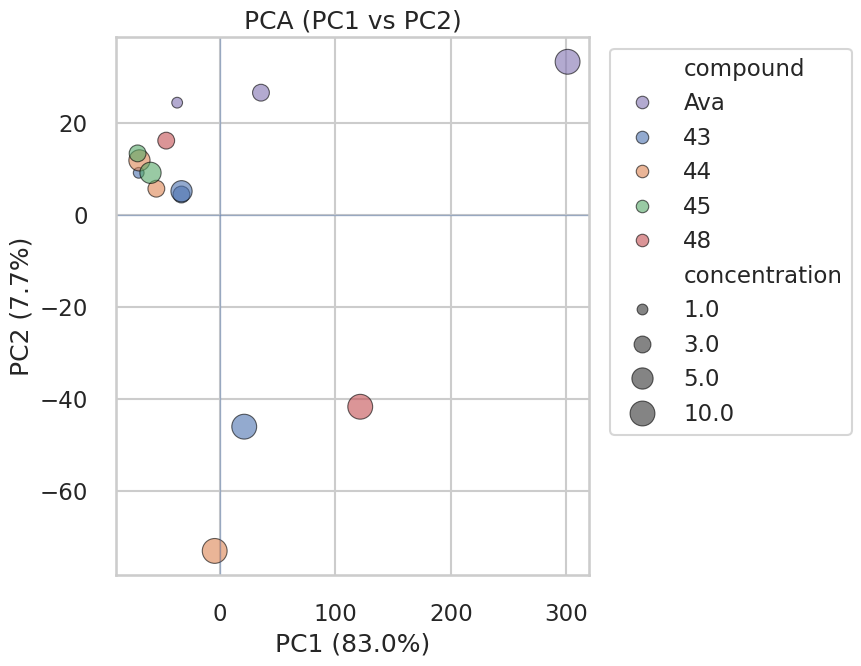

In [19]:
sns.set_theme(style="whitegrid", context="talk")  # nicer defaults

#enforce a nicer order for sizes
pca_df = pca_df.copy()
pca_df["concentration"] = pd.to_numeric(pca_df["concentration"], errors="coerce")

# Build a size mapping (keeps sizes consistent across plots)
unique_conc = sorted(pca_df["concentration"].dropna().unique())
size_min, size_max = 60, 320
size_map = {
    c: size_min + (size_max - size_min) * (i / (len(unique_conc) - 1 if len(unique_conc) > 1 else 1))
    for i, c in enumerate(unique_conc)
}

plt.figure(figsize=(9, 7))
palette = {
    "43": "#4C72B0",   # blue
    "44": "#DD8452",   # orange
    "45": "#55A868",   # green
    "48": "#C44E52",   # red
    "Ava": "#8172B2",  # purple
}
ax = sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="compound",
    size="concentration",
    sizes=size_map,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.60,   # more transparent
    palette=palette
)

ax.axhline(0, lw=1, alpha=0.4)
ax.axvline(0, lw=1, alpha=0.4)

ax.set_title("PCA (PC1 vs PC2)")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")

# Put legend outside
sns.move_legend(ax, "upper left", bbox_to_anchor=(1.02, 1), frameon=True)
plt.tight_layout()
plt.show()

PCA(n_components=14)

<Figure size 900x500 with 0 Axes>

Text(0.5, 1.0, 'PCA Scree Plot (Cumulative Variance)')

Text(0.5, 0, 'Principal Component')

Text(0, 0.5, 'Cumulative variance explained (%)')

(0.0, 120.0)

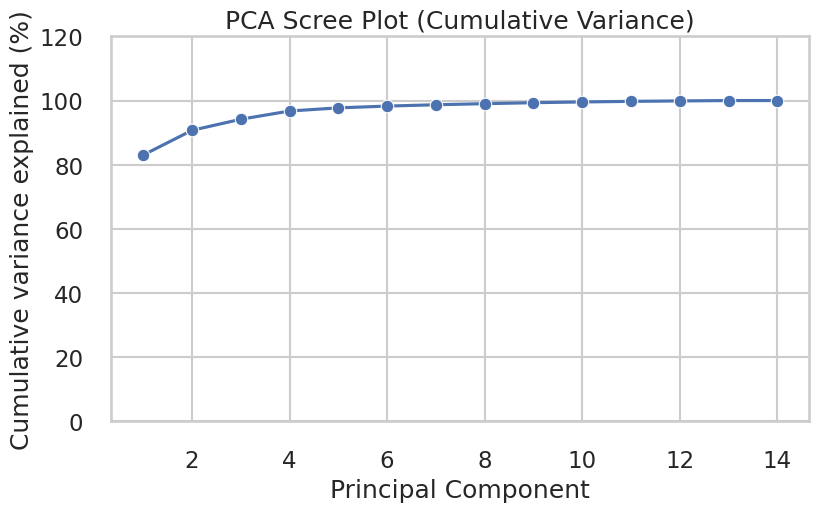

In [20]:
# Recompute PCA with more components for scree
X = df_clean.values

pca_full = PCA(n_components=min(X.shape))
pca_full.fit(X)

explained = pca_full.explained_variance_ratio_ * 100
cum_explained = np.cumsum(explained)

scree_df = pd.DataFrame({
    "PC": np.arange(1, len(explained) + 1),
    "ExplainedVariance": explained,
    "Cumulative": cum_explained
})

plt.figure(figsize=(9, 5))
ax = sns.lineplot(data=scree_df.iloc[:20], x="PC", y="Cumulative", marker="o")
ax.set_title("PCA Scree Plot (Cumulative Variance)")
ax.set_xlabel("Principal Component")
ax.set_ylabel("Cumulative variance explained (%)")
ax.set_ylim(0, 120)
plt.show()

In [21]:
centroids = pca_df.groupby(["compound"]).mean()
pc_cols = centroids.columns[centroids.columns.str.startswith("PC")]

dist_matrix = pd.DataFrame(
    cdist(centroids[pc_cols], centroids[pc_cols], metric="euclidean"),
    index=centroids.index,
    columns=centroids.index
)

dist_matrix.to_excel("20260506_centroids.xlsx")

dist_matrix

compound,43,44,45,48,Ava
compound,,,,,
43,0.000000,18.315593,40.917636,66.678380,133.385519
44,18.315593,0.000000,37.375391,80.723832,150.251556
45,40.917636,37.375391,0.000000,105.878067,166.282694
48,66.678380,80.723832,105.878067,0.000000,74.533599
Ava,133.385519,150.251556,166.282694,74.533599,0.000000


## HEATMAP WITH AGGREGATED FEATURES

<Figure size 1000x400 with 0 Axes>

<Axes: xlabel='Feature Z-score'>

Text(68.38888888888887, 0.5, '')

Text(0.5, 38.444444444444436, '')

Text(0.5, 1.0, 'Feature heatmap')

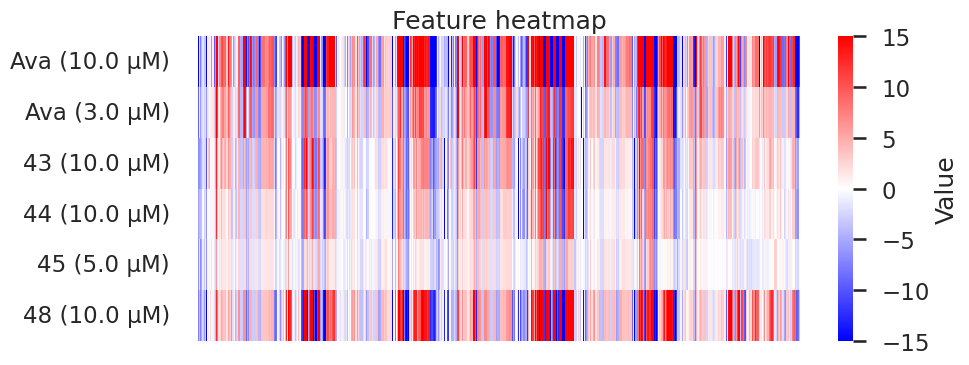

In [22]:
def get_compartment(feature):
    for comp in COMPARTMENTS_ORDER:
        if feature.startswith(comp):
            return comp
    return "Other"

def get_channel(feature):
    for ch in CHANNELS_ORDER:
        if re.search(rf"_{ch}(_|$)", feature):
            return ch
    return "Other"

def sort_feature_key(feature):
    comp = get_compartment(feature)
    ch = get_channel(feature)

    comp_rank = COMPARTMENTS_ORDER.index(comp) if comp in COMPARTMENTS_ORDER else 999
    ch_rank = CHANNELS_ORDER.index(ch) if ch in CHANNELS_ORDER else 999

    return comp_rank, ch_rank, feature

plot_df = df_features_wide.copy()

plot_df = plot_df.set_index("Feature Z-score")

ordered_features = sorted(plot_df.index, key=sort_feature_key)
plot_df = plot_df.loc[ordered_features]


desired_order = [
    ("Ava", 10.0),
    ("Ava", 3.0),
    ("43", 10.0),
    ("44", 10.0),
    ("45", 5.0),
    ("48", 10.0),
]

parsed = [parse_sample_name(c) for c in df_features_wide_median.columns]

col_order = []
for target in desired_order:
    for col, parsed_val in zip(df_features_wide_median.columns, parsed):
        if parsed_val == target:
            col_order.append(col)

plot_df = df_features_wide_median.set_index("Feature Z-score")

plot_df = plot_df[col_order]

clean_labels = [
    re.sub(r"\s*\|.*", "", col)
    for col in plot_df.columns
]

plot_df.columns = clean_labels # can comment if want to keep more info in the heatmap

ordered_features = sorted(plot_df.index, key=sort_feature_key)
plot_df = plot_df.loc[ordered_features]

plot_df_plot = plot_df.clip(-15, 15)

plt.figure(figsize=(10, 4))

sns.heatmap(
    plot_df_plot.T,
    cmap="bwr",
    vmin=-15,
    vmax=15,
    center=0,
    xticklabels=False,
    yticklabels=True,
    cbar_kws={"label": "Value"},
)

plt.ylabel("")
plt.xlabel("")
plt.title("Feature heatmap")

plt.tight_layout()
plt.show()